In [1]:
#importing dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Importing The Data

In [2]:
data = pd.read_csv("C:\\Users\\DELL\\Downloads\\salary\\salary.csv",low_memory=False)

### Loading The Data

In [3]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [4]:
data.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


In [5]:
data.isnull().sum()

AGENCY                          0
AGENCY NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS CODE                      0
CLASS TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY DATE                     0
HRLY RATE                       0
HRS PER WK                      0
MONTHLY                         0
ANNUAL                          0
STATE NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

### EDA

In [7]:
irrelevant_columns = [
    'LAST NAME', 'FIRST NAME', 'MI', 'duplicated', 'multiple_full_time_jobs', 
    'combined_multiple_jobs', 'summed_annual_salary', 'hide_from_search']

In [8]:
data_cleaned = data.drop(columns=irrelevant_columns)


In [9]:
data_cleaned = data_cleaned.dropna(subset=['ANNUAL'])


In [10]:
data_cleaned = data_cleaned.dropna()


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

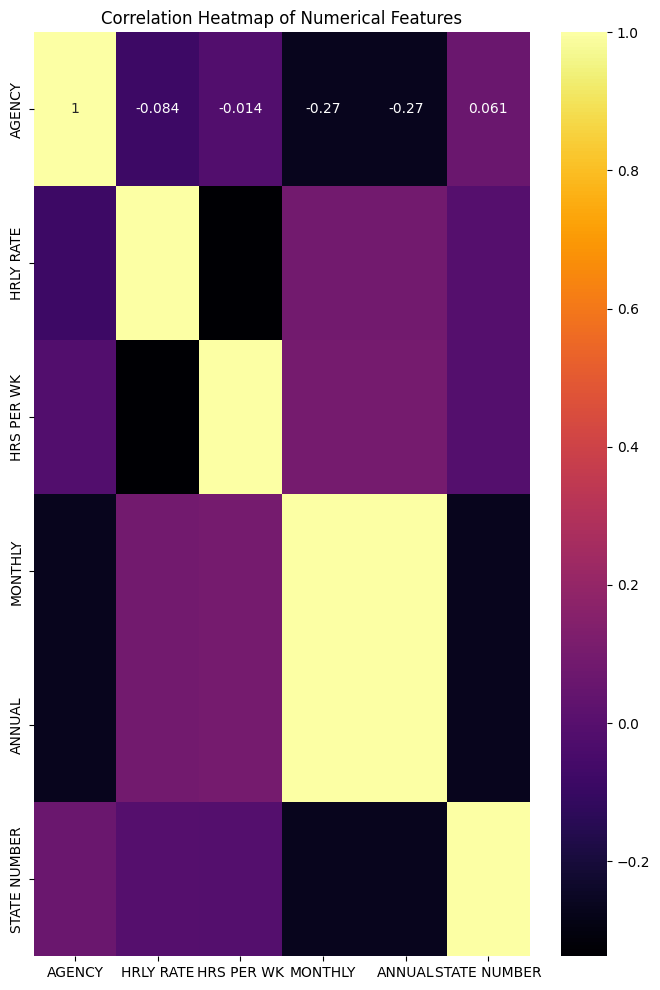

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure only numerical columns are included for the correlation heatmap
numerical_columns = data_cleaned.select_dtypes(include=['number']).columns

# Compute correlations
correlation_matrix = data_cleaned[numerical_columns].corr()

# Plot the heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="inferno")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### Defining features and Target

In [13]:
features = [
    'AGENCY', 'AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 
    'GENDER', 'STATUS', 'HRLY RATE', 'HRS PER WK', 'STATE NUMBER'
]

In [14]:
target = 'ANNUAL'

In [15]:
X = data_cleaned[features]
y = data_cleaned[target]

### OneHotEncoding for categorical, Scaling for numerical

In [16]:
categorical_cols = ['AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS']

In [17]:
numerical_cols = ['HRLY RATE', 'HRS PER WK', 'STATE NUMBER']


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

### Splittig X and y

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 , random_state = 42)

In [20]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

### Model Training

In [21]:
model = LinearRegression()
model.fit(X_train_preprocessed, y_train)


LinearRegression()

In [22]:
y_pred_train = model.predict(X_train_preprocessed)
y_pred_test = model.predict(X_test_preprocessed)


In [23]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)


### Evaluation Metrics

In [24]:
print("Training Set Evaluation:")
print(f"MAE: {mae_train}, RMSE: {rmse_train}, R^2: {r2_train}")


Training Set Evaluation:
MAE: 3191.780299266869, RMSE: 5501.9187568555935, R^2: 0.9517990098317303


In [25]:
print("\nTest Set Evaluation:")
print(f"MAE: {mae_test}, RMSE: {rmse_test}, R^2: {r2_test}")


Test Set Evaluation:
MAE: 3332.558352540347, RMSE: 6865.757849989338, R^2: 0.9266098360503646


### Outliers 

In [26]:
# Step: Detect outliers in salaries
Q1 = data_cleaned['ANNUAL'].quantile(0.25)  # First quartile
Q3 = data_cleaned['ANNUAL'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = data_cleaned[(data_cleaned['ANNUAL'] < lower_bound) | (data_cleaned['ANNUAL'] > upper_bound)]

print(f"Number of outliers: {outliers.shape[0]}")
print("Outliers:\n", outliers[['AGENCY NAME', 'CLASS TITLE', 'ANNUAL']])


Number of outliers: 9031
Outliers:
                                               AGENCY NAME  \
0       COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...   
2       COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...   
5       OFFICE OF THE ATTORNEY GENERAL                ...   
7       TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL     ...   
36      SENATE                                        ...   
...                                                   ...   
149374  STATE PRESERVATION BOARD                      ...   
149393  STATE PRESERVATION BOARD                      ...   
149401  STATE PRESERVATION BOARD                      ...   
149415  STATE PRESERVATION BOARD                      ...   
149475  STATE PRESERVATION BOARD                      ...   

                                              CLASS TITLE     ANNUAL  
0       JUDGE, RETIRED                                ...  114549.84  
2       JUDGE, RETIRED                                ...  114549.84  
5       DIRECTOR I

### Biggest wage disparities between mangers and employees

In [ ]:
# Define job roles indicating managerial positions
manager_keywords = ['Manager', 'Director', 'Supervisor', 'Chief', 'Head', 'Lead']

# Add a column identifying managerial positions
data_cleaned['IS_MANAGER'] = data_cleaned['CLASS TITLE'].str.contains('|'.join(manager_keywords), case=False, na=False)

# Group by agency and role, and calculate average salary for managers and employees
grouped = data_cleaned.groupby(['AGENCY NAME', 'CLASS TITLE', 'IS_MANAGER'])['ANNUAL'].mean().reset_index()

# Pivot to create separate columns for manager and employee salaries
salary_disparity = grouped.pivot_table(
    index=['AGENCY NAME', 'CLASS TITLE'],
    columns='IS_MANAGER',
    values='ANNUAL',
    aggfunc='mean'
).reset_index()

# Rename columns for clarity
salary_disparity.columns = ['AGENCY NAME', 'CLASS TITLE', 'EMPLOYEE_SALARY', 'MANAGER_SALARY']

# Calculate the disparity as the absolute difference and ratio
salary_disparity['DIFFERENCE'] = salary_disparity['MANAGER_SALARY'] - salary_disparity['EMPLOYEE_SALARY']
salary_disparity['RATIO'] = salary_disparity['MANAGER_SALARY'] / salary_disparity['EMPLOYEE_SALARY']

# Sort by the largest disparities
largest_disparities = salary_disparity.sort_values(by='DIFFERENCE', ascending=False).head(10)

# Output the results
print("Top 10 Departments/Roles with Largest Wage Disparities:")
print(largest_disparities)


### Salries and total compensations 

In [ ]:
import matplotlib.pyplot as plt

# Ensure the dataset has a time-based column, e.g., 'YEAR' or 'DATE'
if 'YEAR' in data_cleaned.columns:
    # Group by year, agency, and role, and calculate average salaries and compensations
    trends = data_cleaned.groupby(['YEAR', 'AGENCY NAME', 'CLASS TITLE']).agg(
        average_salary=('ANNUAL', 'mean'),
        average_hrly_rate=('HRLY RATE', 'mean'),
        head_count=('ANNUAL', 'count')  # Assuming each row is an employee
    ).reset_index()

    # Example: Analyze trends for a specific agency or role
    agency_to_plot = 'TEXAS DEPARTMENT OF CRIMINAL JUSTICE'
    role_to_plot = 'CORREC OFFICER IV'

    filtered_trends = trends[
        (trends['AGENCY NAME'] == agency_to_plot) & 
        (trends['CLASS TITLE'] == role_to_plot)
    ]

    # Plot trends
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_trends['YEAR'], filtered_trends['average_salary'], label='Average Salary')
    plt.plot(filtered_trends['YEAR'], filtered_trends['average_hrly_rate'], label='Average Hourly Rate')
    plt.bar(filtered_trends['YEAR'], filtered_trends['head_count'], alpha=0.3, label='Head Count', color='gray')
    plt.title(f"Trends Over Time for {role_to_plot} in {agency_to_plot}")
    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

else:
    print("The dataset does not include a time-based column (e.g., 'YEAR').")


### Challenges faced

There are many challenges we faced some of them are like a particular model takes so much time to give output even it takes hours sometimes ,
and also in handling missing values like which we have to drop or eliminate to achieve good model score and many errors

### Model comaprison report

 Here in this project we used linear regression algorithm and tested it, we got good accuaracy in evaluation metrics like we got 95% accuracy on training data and 93% accuaracy on test data